In [3]:
# %pip install ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
# from ipynb.fs.exploration import extract_windows

In [4]:
df = pd.read_csv("../Data/Export_pupille_CTR_54_F_63ANS_Benson2_2024-08-29_13-26-50.csv", sep=';', skiprows=21, encoding='latin-1')

In [5]:
def extract_windows(data):
    stim_windows = []
    stim_on = np.where(data.iloc[:, 9]=='croix centrale=off')[0]+1
    for i in stim_on:
        stim_off = np.where(data.iloc[i: i+1805, 9]=='consignes=on')[0][0]-1
        stim_windows.append((i, i+stim_off))
    return stim_windows

In [6]:
stim_windows = extract_windows(df)

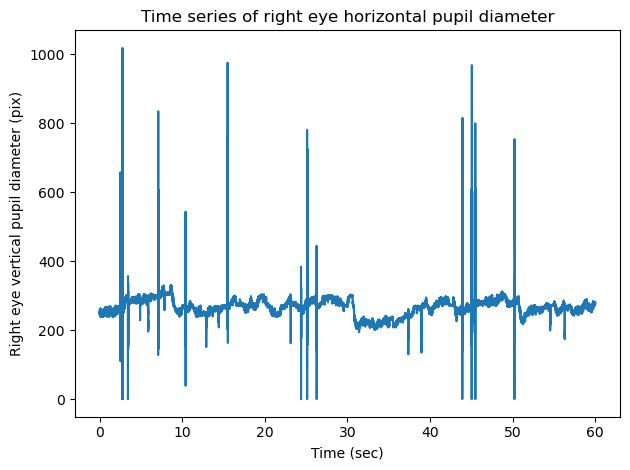

In [7]:
x = np.linspace(0, len(df.loc[:18000, 'RDX (pix)'])/300, len(df.loc[:18000, 'RDX (pix)']))
plt.plot(x, df.loc[:18000, 'RDX (pix)'])
plt.xlabel('Time (sec)')
plt.ylabel('Right eye vertical pupil diameter (pix)')
plt.title('Time series of right eye horizontal pupil diameter')
plt.tight_layout()

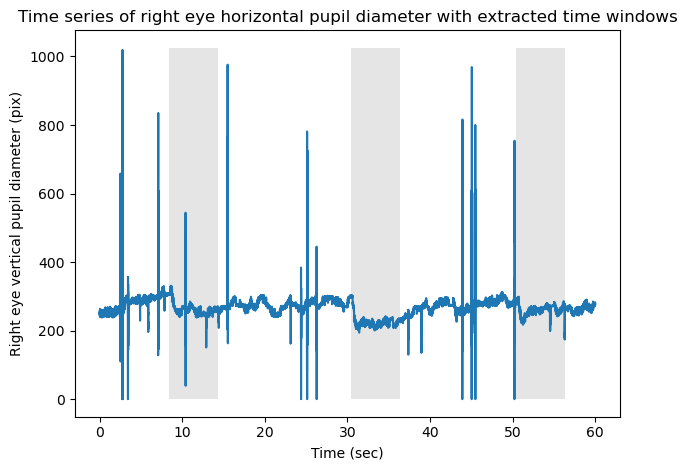

In [8]:
fig, ax = plt.subplots()

x = np.linspace(0, len(df.loc[:18000, 'RDX (pix)'])/300, len(df.loc[:18000, 'RDX (pix)']))
ax.plot(x, df.loc[:18000, 'RDX (pix)'])
ax.set_xlabel('Time (sec)')
ax.set_ylabel('Right eye vertical pupil diameter (pix)')

for i in range(3):
    left = stim_windows[i][0]/300
    width = (stim_windows[i][1]-stim_windows[i][0])/300
    rect = plt.Rectangle((left, 0), width, 1025,
                     facecolor="black", alpha=0.1)
    ax.add_patch(rect)

ax.set_title('Time series of right eye horizontal pupil diameter with extracted time windows')
plt.tight_layout()

In [9]:
order_emotion = []
for stim in stim_windows:
    order_emotion.append(df.loc[stim[0], 'Label'].split('_')[2])

In [12]:
## detect eye blink
def detect_blink(data, sampling_rate=300, ms2add=60):
    '''
    --- Parameters ---
    data: all data streams from a time window
    '''
    
    # Set threshold (threshold is set at: mean - 1.5*mean)
  
    series = data[:, 5] # RDX channel is used because eye blinks are the most clear in this channel
    mean = np.mean(series)/1.5
    
    # extract blink windows
    blink_windows = []

    blink_duration_extension = int(sampling_rate / 1000 * ms2add)
    
    # extract points that cross the threshold
    blink = []
    for i in range(len(series)-1):
        if series[i]<=mean:
            blink.append(i)
            if series[i+1]>mean:
                blink_windows.append((blink[0], blink[-1]))
                blink = []
    
    # extract time window
    for i in range(len(blink_windows)):
        mid = (blink_windows[i][1] - blink_windows[i][0])//2 + blink_windows[i][1]
        blink_windows[i] = (mid-blink_duration_extension, mid+blink_duration_extension)

    return blink_windows

In [13]:
## remove eye blinks
def remove_blink_padding(data, blink_windows):
    data = data.astype(float)

    for i in range(len(data.T)):
        series = data[:, i]
        for j in blink_windows:
            series[j[0]-15: j[1]+15] = np.nan

    return data

In [15]:
# The following function was adapted from Sina Kling's eyeprep repository
# URL: https://github.com/sinaklg/eyeprep
# Retrieved on: June 2, 2026

def interpol_nans(eyetracking_data):
    """
    Interpolate missing (NaN) values in eye-tracking data, filling gaps with the nearest valid data.

    Args:
        eyetracking_data (np.array): Eye-tracking data containing NaN values.

    Returns:
        np.array: Interpolated data with NaNs replaced.
    """
    
    nan_indices = np.isnan(eyetracking_data)

    # Fill NaNs at the start and end with nearest valid values
    if nan_indices[0]:  # If the first value is NaN
        first_valid_idx = np.where(~nan_indices)[0][0]
        eyetracking_data[:first_valid_idx] = eyetracking_data[first_valid_idx]
        
    if nan_indices[-1]:  # If the last value is NaN
        last_valid_idx = np.where(~nan_indices)[0][-1]
        eyetracking_data[last_valid_idx+1:] = eyetracking_data[last_valid_idx]

    # Now interpolate remaining NaNs
    eyetracking_no_nans = np.nan_to_num(eyetracking_data)
    eyetracking_signal_interpolated = np.interp(np.arange(len(eyetracking_data)),
                                               np.where(~nan_indices)[0],
                                               eyetracking_no_nans[~nan_indices])
    
    return eyetracking_signal_interpolated

In [16]:
raw_data = np.array(df.iloc[:, 1:9])

for v in stim_windows:
    blinks = detect_blink(raw_data[v[0]:v[1], :])
    if blinks:
        raw_data[v[0]:v[1], :] = remove_blink_padding(raw_data[v[0]:v[1], :], blinks)
        for i in range(len(raw_data.T)):
            raw_data[v[0]:v[1], i] = interpol_nans(raw_data[v[0]:v[1], i])
data_no_blinks = raw_data

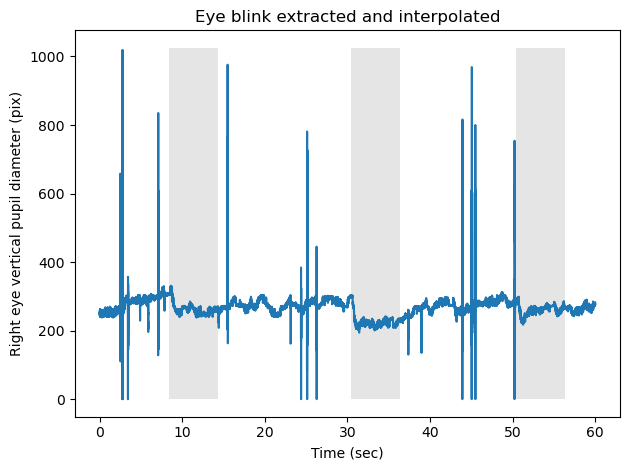

In [17]:
fig, ax = plt.subplots()

x = np.linspace(0, len(data_no_blinks[:18000, 6])/300, len(data_no_blinks[:18000, 6]))
ax.plot(x, data_no_blinks[:18000, 6])
ax.set_xlabel('Time (sec)')
ax.set_ylabel('Right eye vertical pupil diameter (pix)')

for i in range(3):
    left = stim_windows[i][0]/300
    width = (stim_windows[i][1]-stim_windows[i][0])/300
    rect = plt.Rectangle((left, 0), width, 1025,
                     facecolor="black", alpha=0.1)
    ax.add_patch(rect)

ax.set_title('Eye blink extracted and interpolated')
plt.tight_layout()